In [1]:
import os
import sys
import cv2
import numpy as np
import pickle
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split

sys.path.append("..")
from src import config

print(" Setup complete")
print(f"Loading from: {config.KAGGLE_DIR}")
print(f"Classes: {config.TOMATO_CLASS_DISPLAY}")

 Setup complete
Loading from: c:\Users\HP\Downloads\Plant Dieases Classification Model\data\kaggle_plantvillage\PlantVillage
Classes: {'Tomato_Early_blight': 'Early Blight', 'Tomato_Late_blight': 'Late Blight', 'Tomato_Bacterial_spot': 'Bacterial Spot', 'Tomato_healthy': 'Healthy'}


In [2]:
def load_tomato_dataset(use_cache=True):

    if use_cache and os.path.exists(config.TOMATO_CACHE_FILE):
        print(f" Loading from cache: {config.TOMATO_CACHE_FILE}")
        with open(config.TOMATO_CACHE_FILE, "rb") as f:
            data = pickle.load(f)
        return data["X"], data["y"]

    X, y = [], []
    class_map = {cls: i for i, cls in enumerate(config.TOMATO_CLASSES)}
    counts = {}

    for cls in config.TOMATO_CLASSES:
        path = os.path.join(config.KAGGLE_DIR, cls)
        if not os.path.exists(path):
            print(f"  Missing: {path}")
            continue

        files = [f for f in os.listdir(path)
                 if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        print(f" {cls}: {len(files)} images")

        for fname in tqdm(files, desc=f"  {cls[:30]}"):
            img = cv2.imread(os.path.join(path, fname))
            if img is None:
                continue
            img = cv2.resize(img, (config.IMG_SIZE, config.IMG_SIZE),
                             interpolation=cv2.INTER_AREA)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            X.append(img)
            y.append(class_map[cls])

        counts[cls] = len(files)

    X = np.array(X, dtype=np.uint8)
    y = np.array(y, dtype=np.int32)

    os.makedirs(config.PROCESSED_DIR, exist_ok=True)
    with open(config.TOMATO_CACHE_FILE, "wb") as f:
        pickle.dump({"X": X, "y": y}, f)
    print(f"\n Cached to {config.TOMATO_CACHE_FILE}")
    print(f" Total: {len(X)} images")

    # Print distribution
    print("\nClass distribution:")
    for cls, idx in class_map.items():
        print(f"  {config.TOMATO_CLASS_DISPLAY[cls]:18s}: "
              f"{int(np.sum(y == idx))}")

    return X, y

 Tomato_Early_blight: 1000 images


  Tomato_Early_blight: 100%|██████████| 1000/1000 [00:42<00:00, 23.66it/s]


 Tomato_Late_blight: 1909 images


  Tomato_Late_blight: 100%|██████████| 1909/1909 [02:06<00:00, 15.07it/s]


 Tomato_Bacterial_spot: 2127 images


  Tomato_Bacterial_spot: 100%|██████████| 2127/2127 [03:14<00:00, 10.92it/s]


 Tomato_healthy: 1591 images


  Tomato_healthy: 100%|██████████| 1591/1591 [00:52<00:00, 30.35it/s]



 Cached to c:\Users\HP\Downloads\Plant Dieases Classification Model\data\processed\tomato_dataset_cache.pkl
 Total: 6627 images

Class distribution:
  Early Blight      : 1000
  Late Blight       : 1909
  Bacterial Spot    : 2127
  Healthy           : 1591


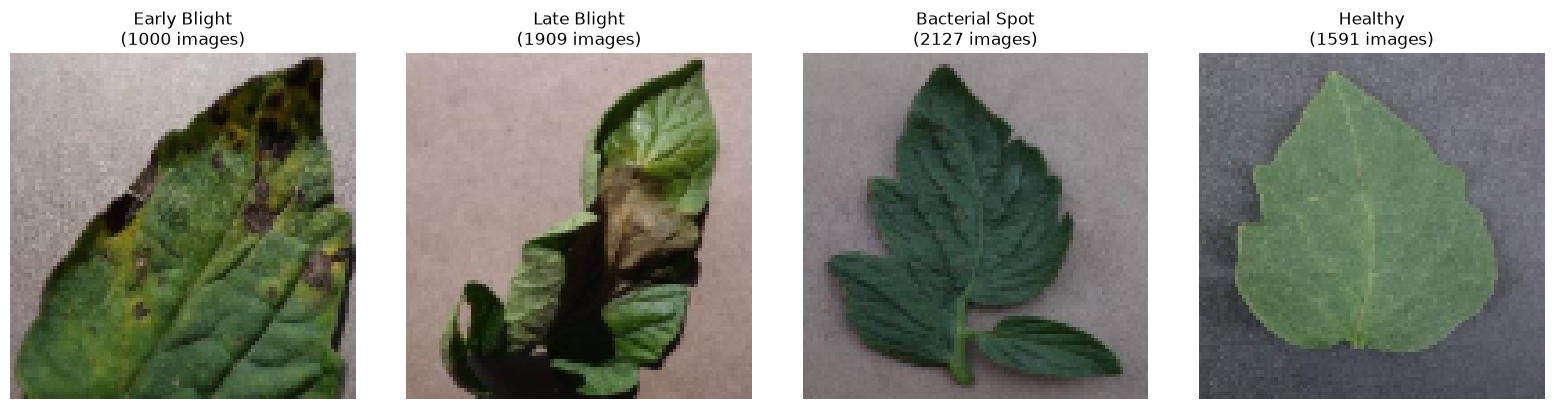

In [3]:
X, y = load_tomato_dataset()

# Show one sample per class
fig, axes = plt.subplots(1, len(config.TOMATO_CLASSES),
                         figsize=(4 * len(config.TOMATO_CLASSES), 4))

for i, cls in enumerate(config.TOMATO_CLASSES):
    idx = np.where(y == i)[0]
    if len(idx) > 0:
        axes[i].imshow(X[idx[0]])
        axes[i].set_title(f"{config.TOMATO_CLASS_DISPLAY[cls]}\n"
                          f"({len(idx)} images)")
        axes[i].axis("off")

plt.tight_layout()
os.makedirs(config.DOCS_DIR, exist_ok=True)
plt.savefig(f"{config.DOCS_DIR}/tomato_samples.png", dpi=100,
            bbox_inches="tight")
plt.show()

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f" Train: {len(X_train)}")
print(f" Val:   {len(X_val)}")
print(f" Test:  {len(X_test)}")

print("\nClass distribution in each split:")
for i, cls in enumerate(config.TOMATO_CLASSES):
    print(f"  {config.TOMATO_CLASS_DISPLAY[cls]:18s} | "
          f"Train: {int(np.sum(y_train == i)):5d} | "
          f"Val: {int(np.sum(y_val == i)):5d} | "
          f"Test: {int(np.sum(y_test == i)):5d}")

splits = {
    "X_train": X_train, "y_train": y_train,
    "X_val": X_val,     "y_val": y_val,
    "X_test": X_test,   "y_test": y_test,
    "classes": config.TOMATO_CLASSES,
    "class_display": config.TOMATO_CLASS_DISPLAY,
}
with open(config.TOMATO_SPLITS_FILE, "wb") as f:
    pickle.dump(splits, f)

print(f"\n Saved splits → {config.TOMATO_SPLITS_FILE}")

 Train: 4638
 Val:   994
 Test:  995

Class distribution in each split:
  Early Blight       | Train:   700 | Val:   150 | Test:   150
  Late Blight        | Train:  1336 | Val:   286 | Test:   287
  Bacterial Spot     | Train:  1489 | Val:   319 | Test:   319
  Healthy            | Train:  1113 | Val:   239 | Test:   239

 Saved splits → c:\Users\HP\Downloads\Plant Dieases Classification Model\data\processed\tomato_splits.pkl
